In [5]:
#LCMV beamforming for deep source localization
import os
import os.path as op
import mne
from mne import setup_volume_source_space
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn.image import index_img, resample_to_img

In [3]:
path = '/Users/immlab/Desktop/IMM-Lab'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')

In [3]:
#Create a source space including cerebellum for fsaverage: 

average_sub = subj = 'fsaverage' #Change this to vml_avg_child to setup averaged volume src for children
bem_dir = op.join(mri_path, subj, 'bem')
fname_aseg = op.join(mri_path, subj, 'mri', 'aseg.mgz')

src_to = mne.read_source_spaces(op.join(mri_path, average_sub, 'bem', f'{average_sub}-ico-5-src.fif'))#change to oct6 for vml_avg_child

model = mne.make_bem_model(subject=subj, ico=5, conductivity=(0.3,),
                           subjects_dir=mri_path)

mne.write_bem_surfaces(op.join(mri_path, subj, 'bem', f'{subj}-bem-model.fif'), model, overwrite=True)

fname_model = op.join(bem_dir, f"{subj}-bem-model.fif")

labels_vol = [ 
    'Right-Cerebellum-Cortex',
    'Right-Cerebellum-White-Matter',
    'Left-Cerebellum-Cortex',
    'Left-Cerebellum-White-Matter'
]

fs_avg_vol_src = setup_volume_source_space(
    subj,
    mri = fname_aseg,
    pos = 5.0,
    bem = fname_model, 
    add_interpolator = True,
    volume_label = labels_vol,
    subjects_dir = mri_path
)

src_to += fs_avg_vol_src
src_to.save(op.join(mri_path, subj, 'bem', f'{subj}-mixed-src.fif'), overwrite=True)
src_to.plot(subjects_dir=mri_path)

    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Creating the BEM geometry...
Going from 5th to 5th subdivision of an icosahedron (n_tri: 20480 -> 20480)
inner skull CM is  -0.53 -21.10   6.21 mm
Surfaces passed the basic topology checks.
Complete.

Overwriting existing file.
BEM              : /Users/immlab/Desktop/IMM-Lab/MRI/fsaverage/bem/fsaverage-bem-model.fif
grid                  : 5.0 mm
mindist               : 5.0 mm
MRI volume            : /Users/immlab/Desktop/IMM-Lab/MRI/fsaverage/mri/aseg.mgz

Reading /Users/immlab/Desktop/IMM-Lab/MRI/fsaverage/mri/aseg.mgz...

Loaded inner skull from /Users/immlab/Desktop/IMM-Lab/MRI/fsaverage/bem/fsaverage-bem-model.fif (10242 nodes)
Surface CM = (  -0.5  -21.1    6.2) mm
Surface fits inside a sphere with radius   98.3 mm
Surface extent:
    x =  -75.3 ...   76.3 mm
    y = -113.4 ...   75.0 mm
    z =  -72.4 ...   88.2 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y = -115.0 .

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   23.0s finished


    594675/16777216 nonzero values for Right-Cerebellum-Cortex
    159416/16777216 nonzero values for Right-Cerebellum-White-Matter
    629759/16777216 nonzero values for Left-Cerebellum-Cortex
    158831/16777216 nonzero values for Left-Cerebellum-White-Matter
[done]
Overwriting existing file.
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    6 source spaces written
Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [6]:
def morph_to_fsaverage(subs, conditions, meg_path, mri_path, src_to):
    """Morph source estimates from subjects to fsaverage."""
    for s in subs:
        print(f'Morphing subject {s}...')
        
        fwd = mne.read_forward_solution(op.join(meg_path, f'vml_meg_{s}', f'{s}-cerebellar-fw-solution-run.fif'), verbose=False)
        src = fwd['src']

        morph = mne.compute_source_morph( 
                src=src,
                subject_from=f"vml_mri_{s}",
                subject_to='fsaverage',
                src_to=src_to,
                subjects_dir=mri_path,
                verbose=False
            )
        
        morph_mat = morph.compute_vol_morph_mat()
        morph.save(op.join(meg_path, f'vml_meg_{s}', f'{s}-morph'), overwrite=True)
        morph = mne.read_source_morph(op.join(meg_path, f'vml_meg_{s}', f'{s}-morph-morph.h5'))

        for cond in conditions: 
            stc = mne.read_source_estimate(op.join(meg_path, f'vml_meg_{s}', f'DS_{s}_cond-{cond}-stc.h5')) 
            morphed_stc = morph.apply(stc)
            morphed_stc.save(op.join(meg_path, f'vml_meg_{s}', f'morphed_DS_{s}_cond-{cond}-stc.h5'), overwrite=True)


conditions = ['run 1 ', 'run 2 ', 'run 3', 'run 4', 'run 5 ']
# conditions = ['right no-rotation', 'left no-rotation', 'right rotation' ,'left rotation']

adult_subs = ['011', '012', '013', '014', '018', '019',  '021', '022', '025', '026', '030', '031']
child_subs = ['002', '003', '004', '006', '009', '010', '015', '016', '027', '028', '029']

morph_to_fsaverage(adult_subs, conditions, meg_path, mri_path, src_to)
# morph_to_fsaverage(child_subs, conditions, meg_path, mri_path, src_to)

Morphing subject 030...


/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_44217/3726160074.py:6: RuntimeWarning: This filename (/Users/immlab/Desktop/IMM-Lab/MEG/vml_meg_030/030-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(meg_path, f'vml_meg_{s}', f'{s}-cerebellar-fw-solution-run.fif'), verbose=False)


Computing sparse volumetric morph matrix (will take some time...)


  0%|          | Vertex : 0/1054 [00:00<?,       ?it/s]

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Morphing subject 031...


/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_44217/3726160074.py:6: RuntimeWarning: This filename (/Users/immlab/Desktop/IMM-Lab/MEG/vml_meg_031/031-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(meg_path, f'vml_meg_{s}', f'{s}-cerebellar-fw-solution-run.fif'), verbose=False)


Computing sparse volumetric morph matrix (will take some time...)


  0%|          | Vertex : 0/1056 [00:00<?,       ?it/s]

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


In [11]:
def get_avg_source_estimates(subs, conditions, meg_path, save_path, prefix):
    """Calculate and save average source estimates for a list of subjects."""
    for cond in conditions:
        # reading source estimates for each subject in the list
        all_stcs = []
        
        for s in subs:
            stc = mne.read_source_estimate(op.join(meg_path, f'vml_meg_{s}', f'morphed_DS_{s}_cond-{cond}-stc.h5'))
            all_stcs.append(stc)
            
        # initialize an array to store the data for all participants
        data_array = np.zeros((len(all_stcs), all_stcs[0].data.shape[0], all_stcs[0].data.shape[1]))
        # np.zeros(6, 21683, 1701)
        
        # check if all source spaces have the same vertices for both hemispheres or volume
        for i, stc in enumerate(all_stcs):
            if stc.data.shape != data_array[0].shape:
                raise ValueError(f"Shape mismatch for subject {i}: {stc.data.shape} vs {data_array[0].shape}")
            
        # fill the data array with source estimate data from each participant
        for i, stc in enumerate(all_stcs):
            data_array[i, :, :] = stc.data
            
        # calculate the average across participants
        average_data = np.mean(data_array, axis=0)
        
        # check that the shape of average data matches the shape of the stc data:
        print(np.shape(average_data), 'is the same as', np.shape(all_stcs[0].data))
        
        # create a new SourceEstimate with the averaged data
        average_stc = mne.MixedSourceEstimate(average_data, vertices=all_stcs[0].vertices, tmin=all_stcs[0].times[0], tstep=np.diff(all_stcs[0].times)[0], subject='fsaverage')
        
        # save the averaged source estimate
        if not os.path.exists(op.join(meg_path, save_path)):
            os.makedirs(op.join(meg_path, save_path))
        
        average_stc.save(op.join(meg_path, save_path, f'VML_{prefix}_morphed-averaged_DS_{cond}'), ftype='h5', overwrite=True)

get_avg_source_estimates(adult_subs, conditions, meg_path, 'adult_morphed_averaged', 'adult')
get_avg_source_estimates(child_subs, conditions, meg_path, 'child_morphed_averaged', 'child')

(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)
(21683, 1701) is the same as (21683, 1701)


In [27]:
# plot averaged STCs (adults)

titles = ['Baseline', 'Early-Learning', 'Late Learning', 'Washout', 'Re-Learning']
i = 0

adult_src = mne.read_source_spaces(op.join(mri_path, 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

for cond in ['run 1 ']:
    print(cond)
    
    avg_stc = mne.read_source_estimate(op.join(meg_path, 'adult_morphed_averaged', f'VML_adult_morphed-averaged_DS_{cond}-stc.h5'))
    brain = avg_stc.plot(src=adult_src, subject='fsaverage', subjects_dir=mri_path, surface='white', hemi='split', views=['lat'], smoothing_steps=10)
    brain.add_text(text=f'{titles[i]}-ADULT-AVERAGED-STC', font_size=20, color='white', x=0.2, y=0.9)
    
    # brain.save_movie(
    #     filename=(op.join(meg_path, f'Child_Avg_{titles[i]}.mov')),
    #     time_dilation=60,  # Adjust this value to control the speed of the video
    #     tmin=0,  # Start time
    #     tmax=0.5,  # End time
    #     framerate=24,  # Frames per second
    #     interpolation='linear'
    # )
    # print('saved movie for child', titles[i])
    # # Close the Brain object to release resources
    # brain.close()
    
    i += 1 


run 1 
Using control points [0.04437368 0.04965449 0.09538593]
Using control points [0.04437368 0.04965449 0.09538593]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it

Using control points [0.04231607 0.04596745 0.0754921 ]


In [9]:
#Plot the averaged STCs (children)

titles = ['Baseline', 'Early-Learning', 'Late Learning', 'Washout', 'Re-Learning']
i = 0

adult_src = mne.read_source_spaces(op.join(mri_path, 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

for cond in conditions:
    print(cond)
    
    avg_stc = mne.read_source_estimate(op.join(meg_path, 'child_morphed_averaged', f'VML_child_morphed-averaged_DS_{cond}-stc.h5'))
    brain = avg_stc.plot(src=adult_src, subject='fsaverage', subjects_dir=mri_path, surface='white', hemi='split', views=['lat'], smoothing_steps=10)
    brain.add_text(text=f'{titles[i]}-CHILDREN-AVERAGED-STC', font_size=20, color='white', x=0.2, y=0.9)
    
    # brain.save_movie(
    #     filename=(op.join(meg_path, f'Child_Avg_{titles[i]}.mov')),
    #     time_dilation=60,  # Adjust this value to control the speed of the video
    #     tmin=0,  # Start time
    #     tmax=0.5,  # End time
    #     framerate=24,  # Frames per second
    #     interpolation='linear'
    # )
    # print('saved movie for child', titles[i])
    # # Close the Brain object to release resources
    # brain.close()
    
    i += 1 

    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    6 source spaces read
run 1
Using control points [0.05961207 0.0665456  0.1200397 ]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
run 2
Using c

Showing: t = 0.367 s, (0.0, -60.0, -20.0) mm, [16, 11, 11] vox, 14536 vertex
Using control points [0.05574634 0.06325761 0.13287958]


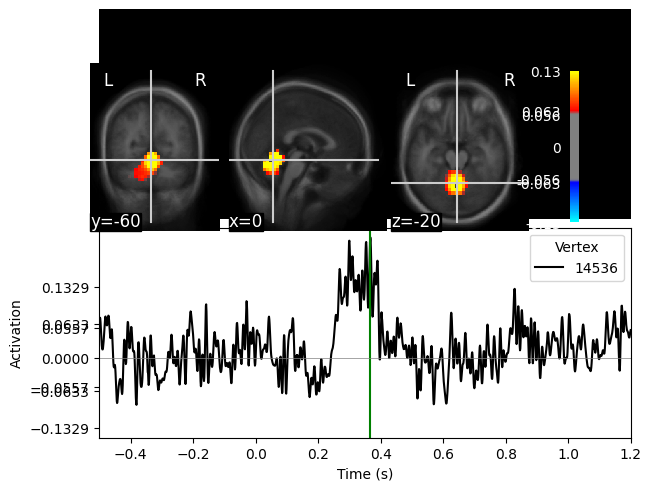

Showing: t = 0.249 s, (-5.0, -45.0, -20.0) mm, [15, 14, 11] vox, 14634 vertex
Using control points [0.04755153 0.05414874 0.11532684]


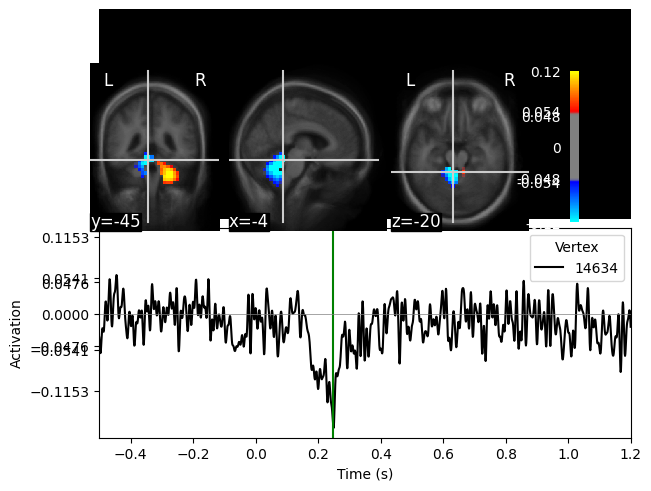

In [68]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'child_morphed_averaged', 'VML_child_morphed-averaged_DS_run 1 -stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'adult_morphed_averaged', 'VML_adult_morphed-averaged_DS_run 1 -stc.h5'))
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

# brain3 = child_stc.plot(src=adult_src,
#     subject='fsaverage',
#     subjects_dir=mri_path, 
#     surface='pial',
#     hemi='both')

Showing: t = 0.333 s, (0.0, -60.0, -20.0) mm, [16, 11, 11] vox, 14536 vertex
Using control points [0.03575685 0.04115158 0.08722075]


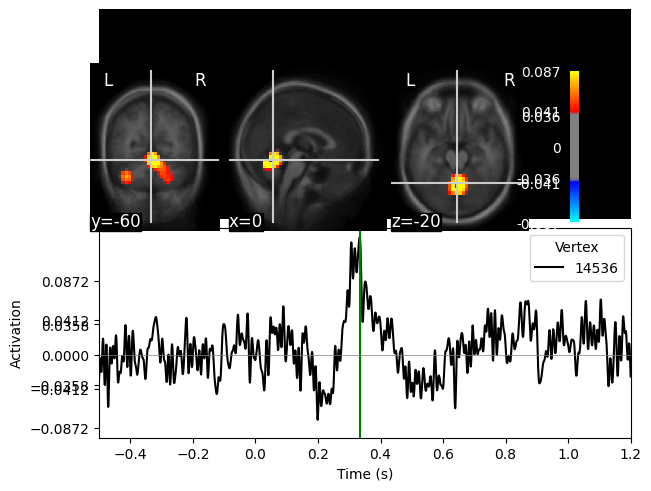

Showing: t = 0.207 s, (-5.0, -55.0, -30.0) mm, [15, 12, 9] vox, 11994 vertex
Using control points [0.03237972 0.03784509 0.0794988 ]


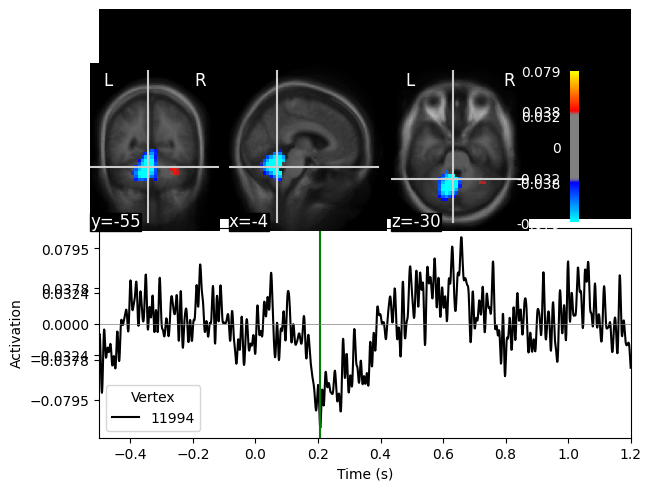

In [69]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'child_morphed_averaged', 'VML_child_morphed-averaged_DS_run 2 -stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'adult_morphed_averaged', 'VML_adult_morphed-averaged_DS_run 2 -stc.h5'))
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

# brain3 = child_stc.plot(src=adult_src,
#     subject='fsaverage',
#     subjects_dir=mri_path, 
#     surface='pial',
#     hemi='both')

Showing: t = 0.339 s, (0.0, -65.0, -25.0) mm, [16, 10, 10] vox, 13216 vertex
Using control points [0.039173   0.04360814 0.07837819]


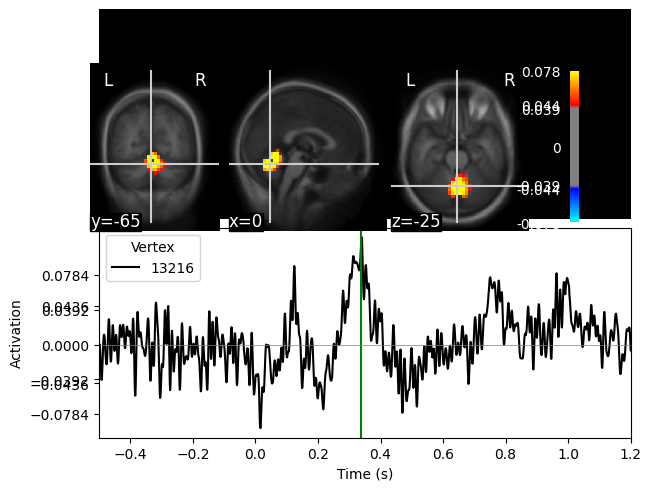

Showing: t = 0.181 s, (0.0, -60.0, -15.0) mm, [16, 11, 12] vox, 15823 vertex
Using control points [0.037654   0.04418321 0.08725759]


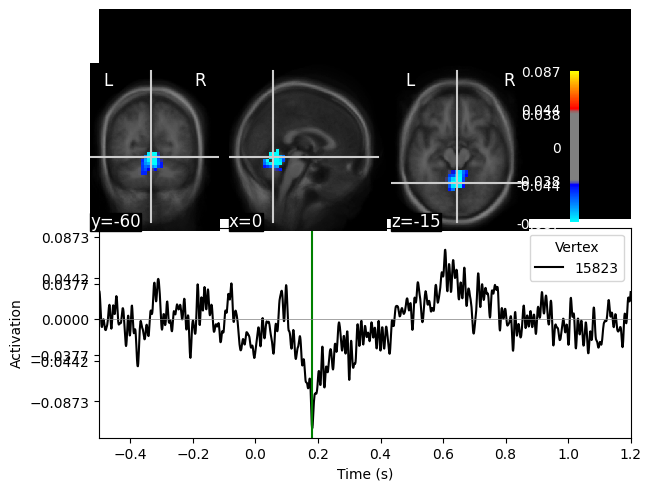

In [70]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'child_morphed_averaged', 'VML_child_morphed-averaged_DS_run 3-stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'adult_morphed_averaged', 'VML_adult_morphed-averaged_DS_run 3-stc.h5'))
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

# brain3 = child_stc.plot(src=adult_src,
#     subject='fsaverage',
#     subjects_dir=mri_path, 
#     surface='pial',
#     hemi='both')

Showing: t = 0.220 s, (0.0, -70.0, -25.0) mm, [16, 9, 10] vox, 13183 vertex
Using control points [0.03701374 0.0415988  0.07490482]


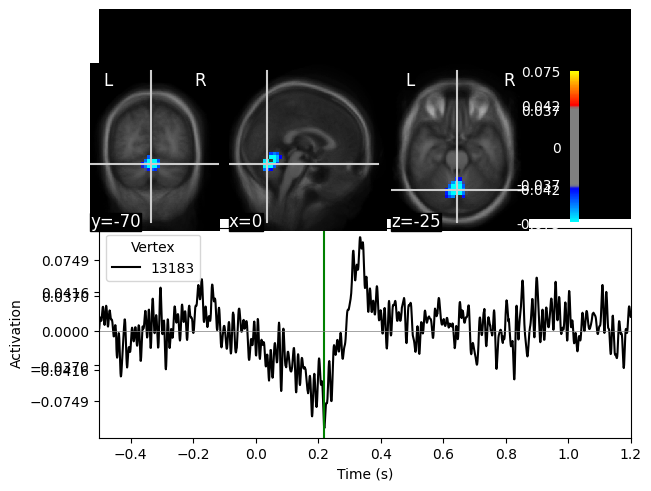

Showing: t = 0.626 s, (-15.0, -70.0, -35.0) mm, [13, 9, 8] vox, 10606 vertex
Using control points [0.03413706 0.03875762 0.07634829]


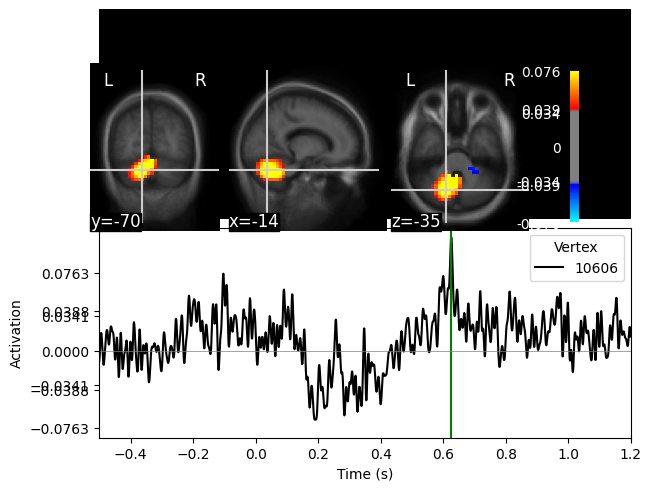

In [71]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'child_morphed_averaged', 'VML_child_morphed-averaged_DS_run 4-stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'adult_morphed_averaged', 'VML_adult_morphed-averaged_DS_run 4-stc.h5'))
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

# brain3 = child_stc.plot(src=adult_src,
#     subject='fsaverage',
#     subjects_dir=mri_path, 
#     surface='pial',
#     hemi='both')

Showing: t = 0.503 s, (0.0, -60.0, -20.0) mm, [16, 11, 11] vox, 14536 vertex
Using control points [0.04456625 0.04959606 0.08593052]


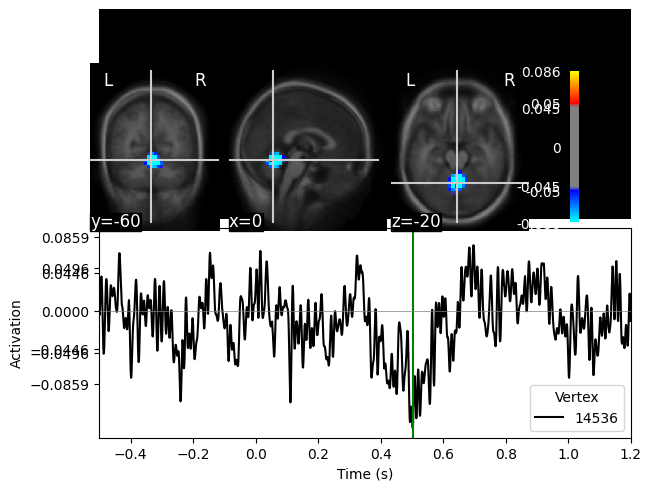

Showing: t = 0.236 s, (-5.0, -55.0, -30.0) mm, [15, 12, 9] vox, 11994 vertex
Using control points [0.03891414 0.04581899 0.0927194 ]


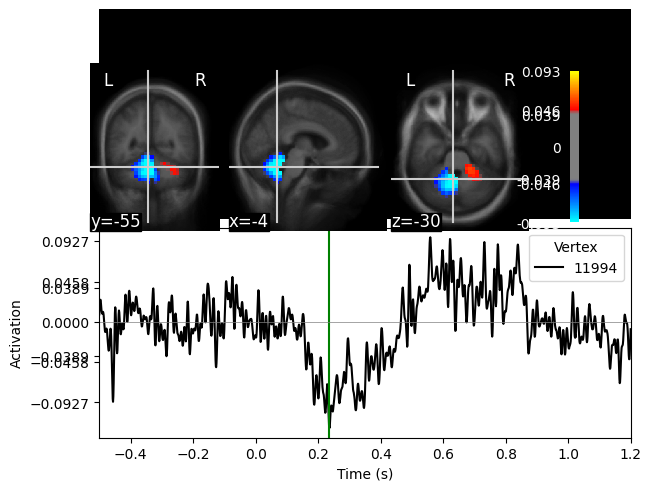

In [72]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'child_morphed_averaged', 'VML_child_morphed-averaged_DS_run 5 -stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'adult_morphed_averaged', 'VML_adult_morphed-averaged_DS_run 5 -stc.h5'))
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

# brain3 = child_stc.plot(src=adult_src,
#     subject='fsaverage',
#     subjects_dir=mri_path,
#     surface='pial',
#     hemi='both')

In [4]:
conditions = ['run 1 ', 'run 2 ', 'run 3', 'run 4', 'run 5 ']
people = ['child', 'adult']
src_path = op.join(mri_path, 'fsaverage', 'bem', 'fsaverage-mixed-src.fif')
src = mne.read_source_spaces(src_path)

for person in people:
    for cond in conditions:
        cond_clean = cond.strip().replace(' ', '')
        stc_path = op.join(meg_path, f'{person}_morphed_averaged', f'VML_{person}_morphed-averaged_DS_{cond}-stc.h5')
        out_path = op.join(meg_path, f'{person}_morphed_averaged', f'VML_{person}_morphed-DS_{cond_clean}_4d_downsampled.nii.gz')
        
        # Load and process
        stc = mne.read_source_estimate(stc_path)
        stc_resamp = stc.copy().resample(50)
        vol_stc = stc_resamp.volume()
        nii = vol_stc.as_volume(src, mri_resolution=True)
        nib.save(nii, out_path)
        print(f"Saved downsampled NIfTI for {cond.strip()} to {out_path}")

    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    6 source spaces read
    [done]
    6 source spaces read
Saved downsampled 4D NIfTI to /Users/immlab/Desktop/IMM-Lab/MEG/adult_morphed_averaged/VML_adult_morphed-DS_run1_4d_downsampled.nii.gz
Saved downsampled 4D NIfTI to /Users/immlab/Desktop/IMM-Lab/MEG/adult_morphed_averaged/VML_adult_morphed-DS_run1_4d_downsampled.nii.gz


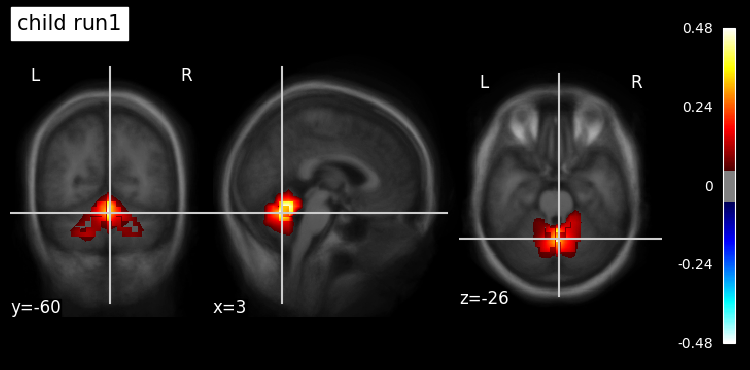

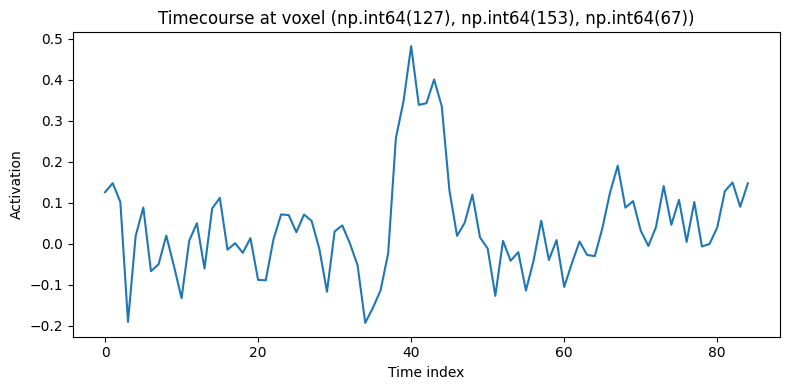

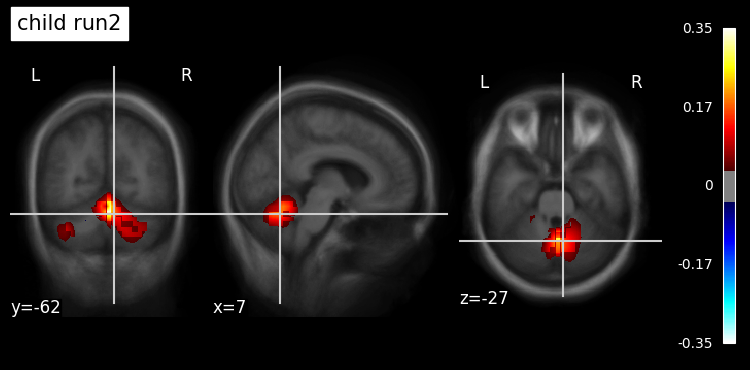

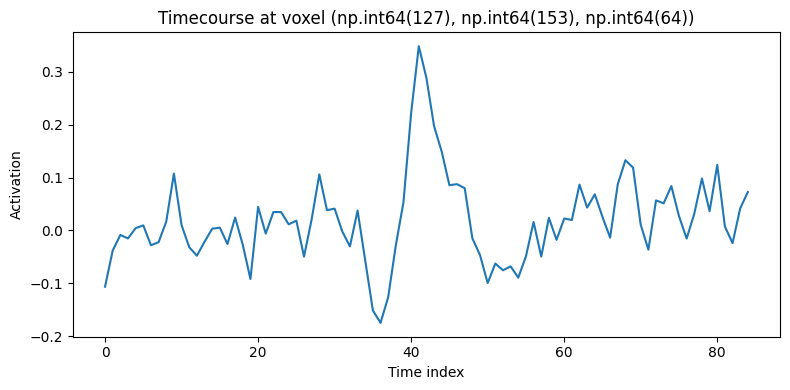

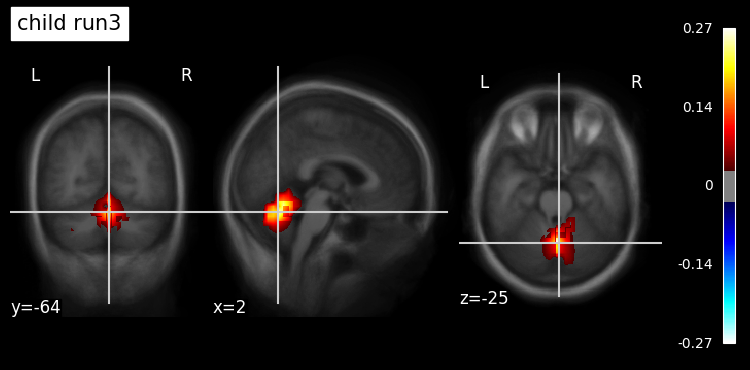

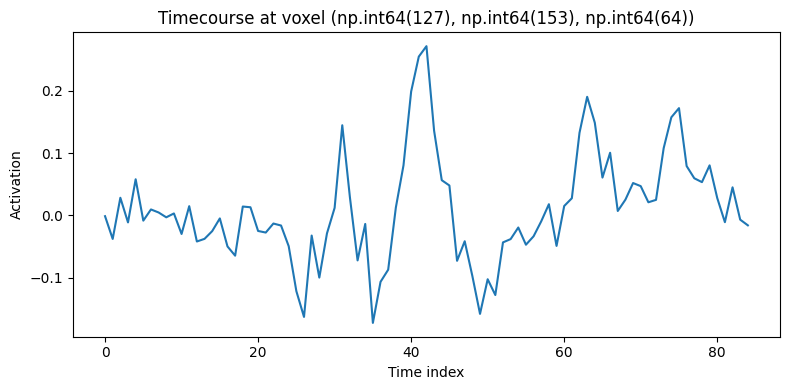

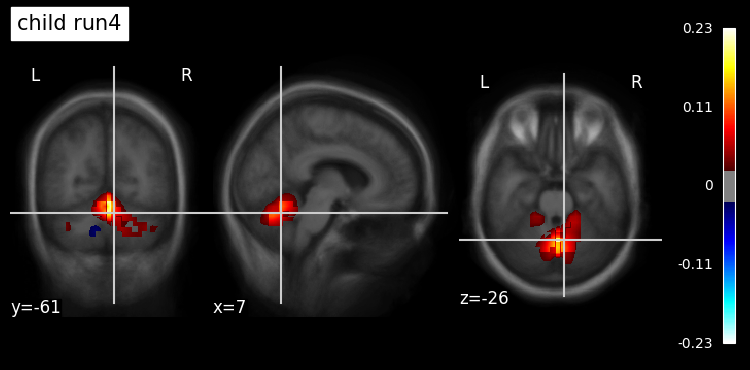

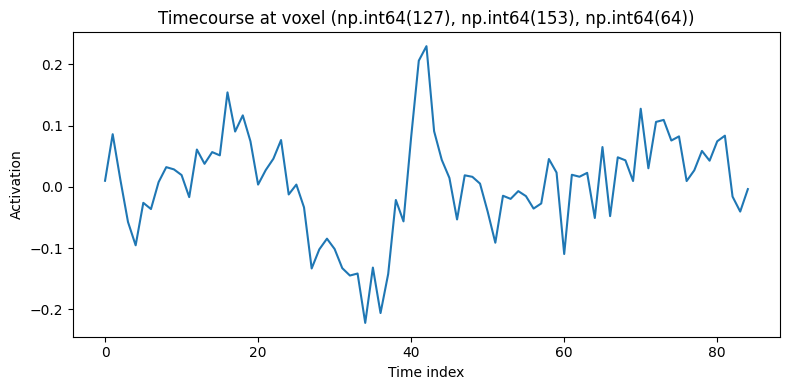

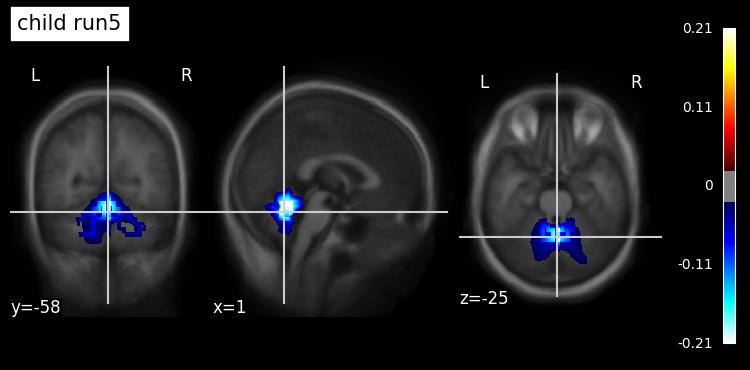

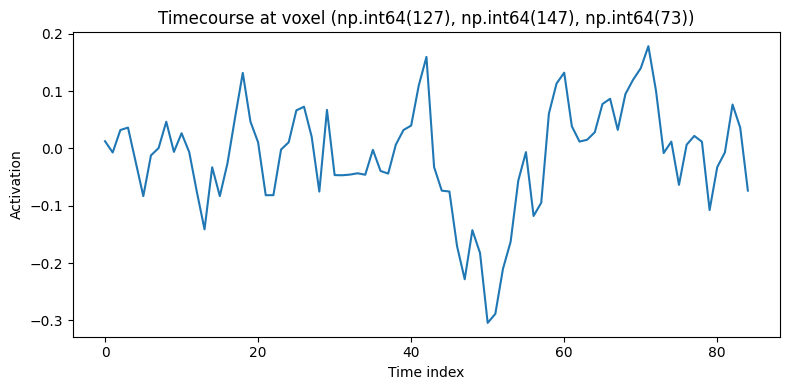

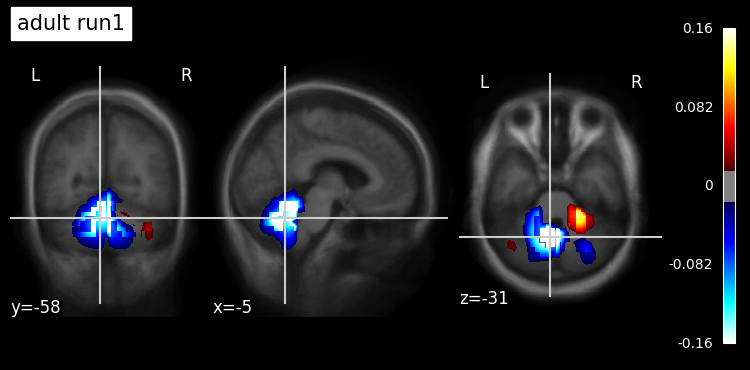

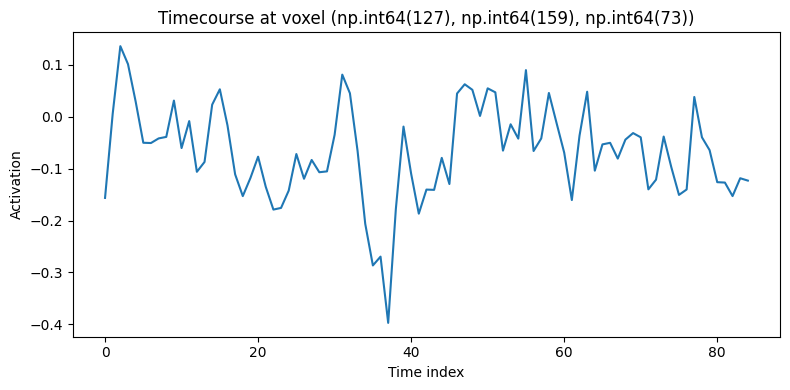

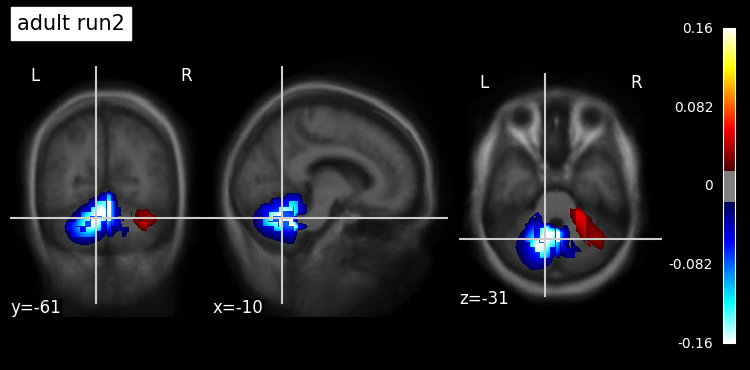

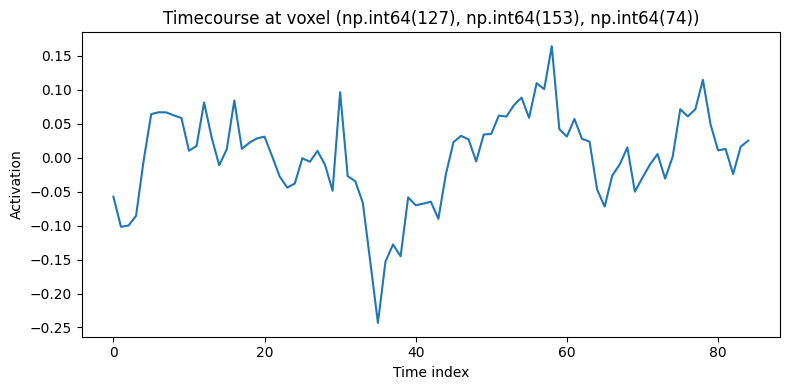

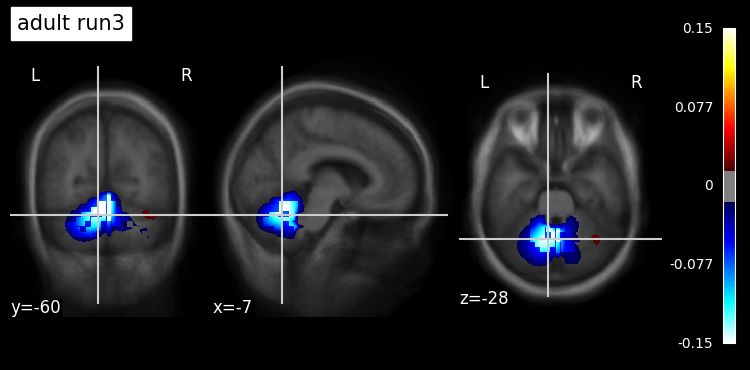

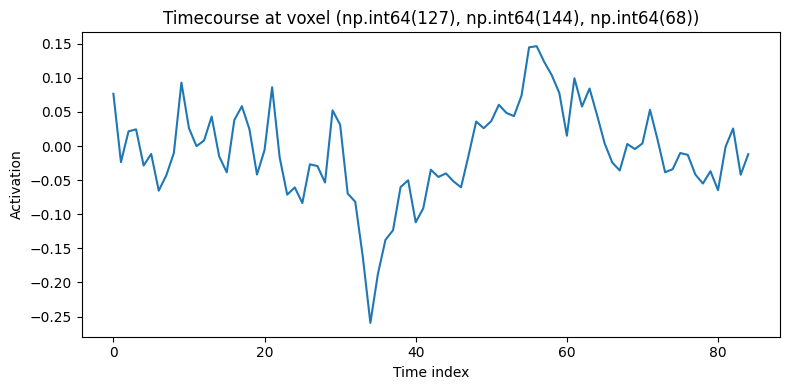

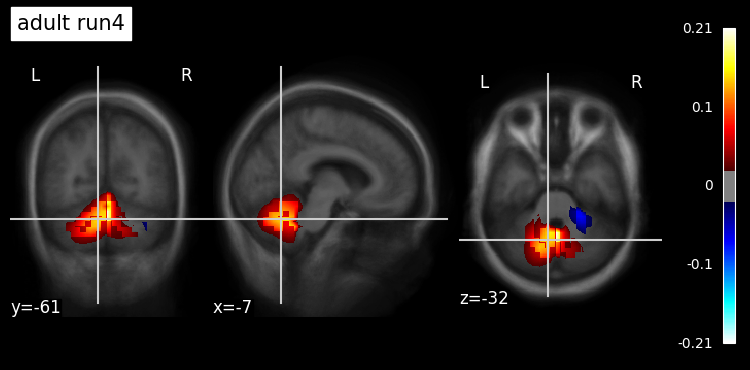

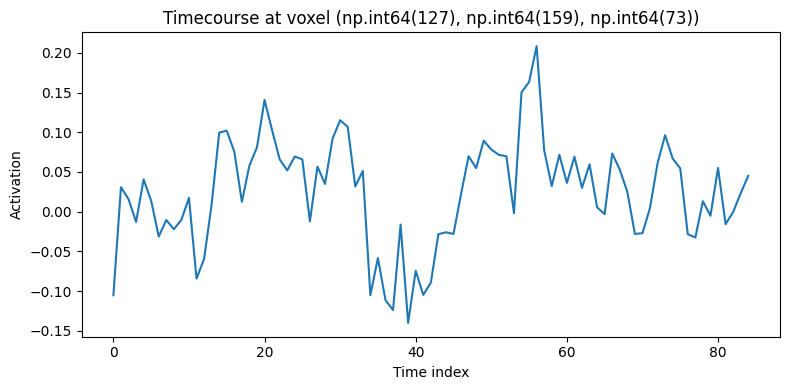

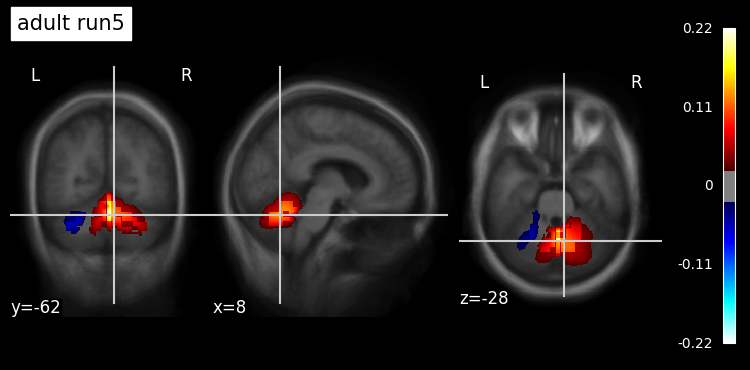

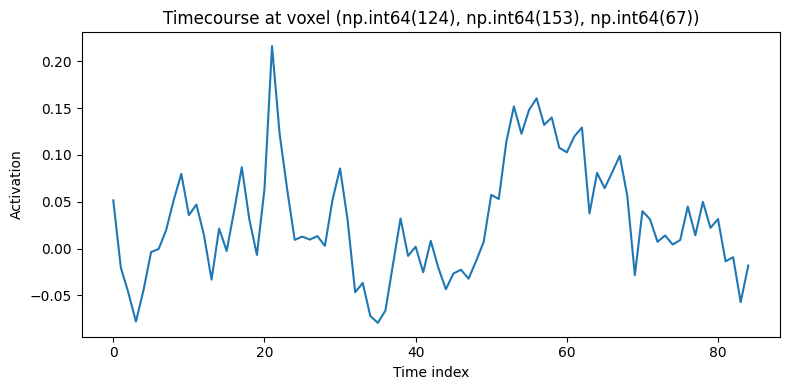

In [7]:
conditions = ['run1', 'run2', 'run3', 'run4', 'run5']

for person in people:  
    for cond in conditions:
        # Paths
        nifti_path = op.join(meg_path, f'{person}_morphed_averaged', f'VML_{person}_morphed-DS_{cond}_4d_downsampled.nii.gz')
        t1_path = op.join(mri_path, 'fsaverage', 'mri', 'T1.mgz')
        t1_nii_path = t1_path.replace('.mgz', '.nii.gz')

        # Load images
        img = nib.load(nifti_path)
        t1_img = nib.load(t1_nii_path)

        # Resample T1 to match activation image if needed
        if not np.allclose(img.header.get_zooms()[:3], t1_img.header.get_zooms()[:3]) or img.shape[:3] != t1_img.shape[:3]:
            t1_img_resamp = resample_to_img(t1_img, img, interpolation='continuous')
        else:
            t1_img_resamp = t1_img

        # Pick a time index with strong activation (e.g., the peak)
        data = img.get_fdata()
        peak_idx = np.unravel_index(np.abs(data).argmax(), data.shape)
        peak_time_idx = peak_idx[3]
        peak_voxel = peak_idx[:3]
        single_img = index_img(img, peak_time_idx)

        # Plot the brain image with overlay
        plotting.plot_stat_map(
            single_img,
            bg_img=t1_img_resamp,
            display_mode='ortho',
            threshold=np.nanmax(data) * 0.1 if np.nanmax(data) > 0 else None,
            vmax=np.nanmax(data) if np.nanmax(data) > 0 else None,
            title=f'{person} {cond}',
            colorbar=True
        )
        plt.show()

        # Plot the timecourse at the peak voxel
        voxel_timecourse = data[peak_voxel[0], peak_voxel[1], peak_voxel[2], :]
        plt.figure(figsize=(8, 4))
        plt.plot(voxel_timecourse)
        plt.title(f"Timecourse at voxel {peak_voxel}")
        plt.xlabel("Time index")
        plt.ylabel("Activation")
        plt.tight_layout()
        plt.show()